In [119]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [120]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

print(f"Train: {train_df.shape}")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")


Train: (129477, 42)
Val:   (31739, 42)
Test:  (12017, 42)


In [ ]:
exclude_cols = ["log_price", "ClosePrice", "CloseDate", "price_ratio"]
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df["log_price"]
y_val = val_df["log_price"]
y_test = test_df["log_price"]

print(f"Feature count: {len(feature_cols)}")


Feature count: 38


In [122]:
feature_type_summary = pd.DataFrame(
    {
        "feature": X_train.columns,
        "dtype": X_train.dtypes.astype(str).values,
    }
)

pd.set_option("display.max_rows", None)
print(feature_type_summary.sort_values("dtype"))


                          feature    dtype
37          AttachedGarageYN_True     bool
35             PoolPrivateYN_True     bool
34          PoolPrivateYN_Missing     bool
33                    ViewYN_True     bool
32                 ViewYN_Missing     bool
36       AttachedGarageYN_Missing     bool
17                    LotSizeArea  float64
16                   LotSizeAcres  float64
15              LotSizeSquareFeet  float64
14                 AssociationFee  float64
13                   ParkingTotal  float64
12                   GarageSpaces  float64
0                    City_encoded  float64
10                      YearBuilt  float64
9           BathroomsTotalInteger  float64
8                   BedroomsTotal  float64
7                      LivingArea  float64
6                       Longitude  float64
5                        Latitude  float64
1              PostalCode_encoded  float64
2          CountyOrParish_encoded  float64
3            MLSAreaMajor_encoded  float64
4      High

## Normalize numerical features

In [123]:
bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
missing_flag_cols = [c for c in X_train.columns if c.endswith("_missing")]

no_scale_cols = list(set(bool_cols + missing_flag_cols))
scale_cols = [c for c in X_train.columns if c not in no_scale_cols]

print(f"Columns to scale: {len(scale_cols)}")
print(scale_cols)
print(f"\nColumns NOT to scale (binary flags/dummies): {len(no_scale_cols)}")
print(no_scale_cols)


Columns to scale: 18
['City_encoded', 'PostalCode_encoded', 'CountyOrParish_encoded', 'MLSAreaMajor_encoded', 'HighSchoolDistrict_encoded', 'Latitude', 'Longitude', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt', 'Stories', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'LotSizeSquareFeet', 'LotSizeAcres', 'LotSizeArea']

Columns NOT to scale (binary flags/dummies): 20
['AttachedGarageYN_Missing', 'GarageSpaces_missing', 'ViewYN_True', 'AssociationFee_missing', 'Stories_missing', 'HighSchoolDistrict_missing', 'YearBuilt_missing', 'BathroomsTotalInteger_missing', 'PoolPrivateYN_True', 'LotSizeSquareFeet_missing', 'ParkingTotal_missing', 'AttachedGarageYN_True', 'MLSAreaMajor_missing', 'LotSizeAcres_missing', 'Latitude_missing', 'LotSizeArea_missing', 'ViewYN_Missing', 'Longitude_missing', 'PoolPrivateYN_Missing', 'LivingArea_missing']


In [124]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val_scaled[scale_cols] = scaler.transform(X_val[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print("Scaling done (binary/flag columns left unscaled).")
print(X_train_scaled[scale_cols].describe().loc[["mean", "std"]])


Scaling done (binary/flag columns left unscaled).
      City_encoded  PostalCode_encoded  CountyOrParish_encoded  \
mean        0.0000              0.0000                  0.0000   
std         1.0000              1.0000                  1.0000   

      MLSAreaMajor_encoded  HighSchoolDistrict_encoded  Latitude  Longitude  \
mean                0.0000                      0.0000    0.0000    -0.0000   
std                 1.0000                      1.0000    1.0000     1.0000   

      LivingArea  BedroomsTotal  BathroomsTotalInteger  YearBuilt  Stories  \
mean      0.0000        -0.0000                -0.0000     0.0000   0.0000   
std       1.0000         1.0000                 1.0000     1.0000   1.0000   

      GarageSpaces  ParkingTotal  AssociationFee  LotSizeSquareFeet  \
mean        0.0000       -0.0000          0.0000            -0.0000   
std         1.0000        1.0000          1.0000             1.0000   

      LotSizeAcres  LotSizeArea  
mean        0.0000      -0.000

### VIF

In [125]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train_scaled.astype(float).copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])
]

vif_data = vif_data[vif_data["feature"] != "const"]
vif_data = vif_data.sort_values("VIF", ascending=False)

pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.2f}".format)
print(vif_data)


/opt/base-uv/.venv/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                          feature    VIF
31               Latitude_missing    inf
29              Longitude_missing    inf
24      LotSizeSquareFeet_missing 917.36
26            LotSizeArea_missing 815.60
25           LotSizeAcres_missing 207.65
6                        Latitude  20.51
7                       Longitude  17.03
2              PostalCode_encoded  11.60
1                    City_encoded  10.95
17                   LotSizeAcres   6.50
21           MLSAreaMajor_missing   5.15
4            MLSAreaMajor_encoded   4.02
10          BathroomsTotalInteger   3.96
8                      LivingArea   3.77
5      HighSchoolDistrict_encoded   3.49
3          CountyOrParish_encoded   3.37
33                 ViewYN_Missing   3.04
19         AssociationFee_missing   2.93
35          PoolPrivateYN_Missing   2.63
16              LotSizeSquareFeet   2.60
20     HighSchoolDistrict_missing   2.58
9                   BedroomsTotal   2.06
22                Stories_missing   2.04
38          Atta

In [126]:
print(train_df[["Latitude_missing", "Longitude_missing"]].value_counts())


Latitude_missing  Longitude_missing
0                 0                    129468
1                 1                         9
Name: count, dtype: int64


In [127]:
print(
    train_df[
        ["LotSizeSquareFeet_missing", "LotSizeAcres_missing", "LotSizeArea_missing"]
    ].value_counts()
)


LotSizeSquareFeet_missing  LotSizeAcres_missing  LotSizeArea_missing
0                          0                     0                      127246
1                          1                     1                        2209
0                          1                     0                          10
1                          0                     0                          10
                           1                     0                           2
Name: count, dtype: int64


In [128]:
print(train_df["LotSizeSquareFeet_missing"].sum())
print(train_df["LotSizeAcres_missing"].sum())
print(train_df["LotSizeArea_missing"].sum())


2221
2221
2209


In [129]:
cols_to_drop = [
    "Longitude_missing",
    "LotSizeSquareFeet_missing",
    "LotSizeArea_missing",
]

X_train_scaled = X_train_scaled.drop(columns=cols_to_drop)
X_val_scaled = X_val_scaled.drop(columns=cols_to_drop)
X_test_scaled = X_test_scaled.drop(columns=cols_to_drop)

print(f"Feature count after dropping: {X_train_scaled.shape[1]}")


Feature count after dropping: 35


## Linear Regression

In [130]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [131]:
X_train_sm = sm.add_constant(X_train_scaled.astype(float))
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                 2.285e+04
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        21:53:29   Log-Likelihood:                -4948.8
No. Observations:              129477   AIC:                             9970.
Df Residuals:                  129441   BIC:                         1.032e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [132]:
coef_summary = pd.DataFrame(
    {
        "coefficient": ols_model.params,
        "abs_coefficient": ols_model.params.abs(),
        "p.value": ols_model.pvalues,
    }
)

coef_summary = coef_summary.drop("const")


def sig_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "."
    return ""


coef_summary["sig"] = coef_summary["p.value"].apply(sig_stars)

main_features = coef_summary[~coef_summary.index.str.endswith("_missing")]
main_features = main_features.sort_values("abs_coefficient", ascending=False)

pd.set_option("display.float_format", "{:.4f}".format)
print(main_features)


                            coefficient  abs_coefficient  p.value  sig
PostalCode_encoded               0.3168           0.3168   0.0000  ***
LivingArea                       0.1823           0.1823   0.0000  ***
Longitude                       -0.1067           0.1067   0.0000  ***
Latitude                        -0.1064           0.1064   0.0000  ***
City_encoded                     0.1022           0.1022   0.0000  ***
BathroomsTotalInteger            0.0743           0.0743   0.0000  ***
PoolPrivateYN_Missing            0.0684           0.0684   0.0000  ***
PoolPrivateYN_True               0.0678           0.0678   0.0000  ***
AttachedGarageYN_Missing        -0.0569           0.0569   0.0000  ***
CountyOrParish_encoded           0.0540           0.0540   0.0000  ***
ViewYN_True                      0.0369           0.0369   0.0000  ***
Stories                         -0.0244           0.0244   0.0000  ***
BedroomsTotal                    0.0197           0.0197   0.0000  ***
Attach

In [133]:
missing_flags_only = coef_summary[coef_summary.index.str.endswith("_missing")]
missing_flags_only = missing_flags_only.sort_values("abs_coefficient", ascending=False)
print(missing_flags_only)


                               coefficient  abs_coefficient  p.value  sig
LivingArea_missing                  0.5313           0.5313   0.0000  ***
YearBuilt_missing                   0.1066           0.1066   0.0001  ***
BathroomsTotalInteger_missing      -0.0896           0.0896   0.1317     
Latitude_missing                    0.0705           0.0705   0.4004     
ParkingTotal_missing                0.0616           0.0616   0.8065     
AssociationFee_missing              0.0499           0.0499   0.0000  ***
Stories_missing                    -0.0359           0.0359   0.0000  ***
GarageSpaces_missing                0.0348           0.0348   0.0000  ***
MLSAreaMajor_missing                0.0256           0.0256   0.0000  ***
LotSizeAcres_missing               -0.0071           0.0071   0.2146     
HighSchoolDistrict_missing         -0.0068           0.0068   0.0073   **


In [134]:
y_pred_train = model.predict(X_train_scaled)

r2_train = r2_score(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)

print(f"Train R²:   {r2_train:.4f}")
print(f"Train RMSE (log scale): {rmse_train:.4f}")
print(f"Train MAE  (log scale): {mae_train:.4f}")


Train R²:   0.8607
Train RMSE (log scale): 0.2514
Train MAE  (log scale): 0.1643


In [135]:
y_pred_val = model.predict(X_val_scaled)
r2_val = r2_score(y_val, y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae_val = mean_absolute_error(y_val, y_pred_val)

print(f"Val R²:   {r2_val:.4f}")
print(f"Val RMSE (log scale): {rmse_val:.4f}")
print(f"Val MAE  (log scale): {mae_val:.4f}")


Val R²:   0.8528
Val RMSE (log scale): 0.2644
Val MAE  (log scale): 0.1709


In [136]:
y_pred_test = model.predict(X_test_scaled)

r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Test R²:   {r2_test:.4f}")
print(f"Test RMSE (log scale): {rmse_test:.4f}")
print(f"Test MAE  (log scale): {mae_test:.4f}")


Test R²:   0.8602
Test RMSE (log scale): 0.2558
Test MAE  (log scale): 0.1714


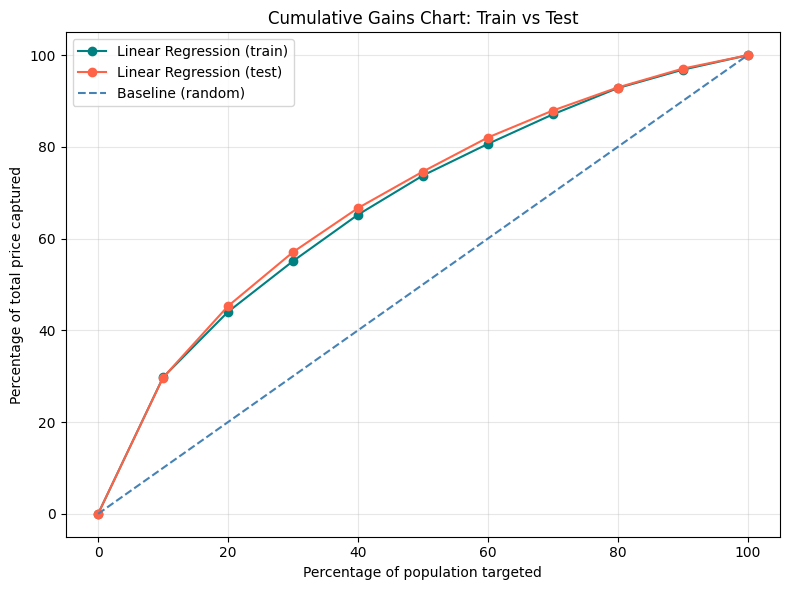

In [137]:
def cumulative_gains(y_true, y_pred, n_bins=10):
    """
    Adapted cumulative gains chart for regression.
    Sort by predicted value, then track cumulative % of actual price captured.
    """
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df = df.sort_values("y_pred", ascending=False).reset_index(drop=True)

    df["cum_actual"] = df["y_true"].cumsum()
    total_actual = df["y_true"].sum()
    df["cum_pct_actual"] = df["cum_actual"] / total_actual * 100
    df["cum_pct_population"] = (np.arange(1, len(df) + 1) / len(df)) * 100

    bin_edges = np.linspace(0, len(df), n_bins + 1).astype(int)
    pct_population = [0]
    pct_actual = [0]
    for edge in bin_edges[1:]:
        pct_population.append(df["cum_pct_population"].iloc[edge - 1])
        pct_actual.append(df["cum_pct_actual"].iloc[edge - 1])

    return pct_population, pct_actual


train_actual_price = np.exp(y_train)
train_pred_price = np.exp(y_pred_train)
test_actual_price = np.exp(y_test)
test_pred_price = np.exp(y_pred_test)

pop_train, gain_train = cumulative_gains(train_actual_price, train_pred_price)
pop_test, gain_test = cumulative_gains(test_actual_price, test_pred_price)

plt.figure(figsize=(8, 6))
plt.plot(
    pop_train, gain_train, marker="o", label="Linear Regression (train)", color="teal"
)
plt.plot(
    pop_test, gain_test, marker="o", label="Linear Regression (test)", color="tomato"
)
plt.plot(
    [0, 100], [0, 100], linestyle="--", color="steelblue", label="Baseline (random)"
)

plt.xlabel("Percentage of population targeted")
plt.ylabel("Percentage of total price captured")
plt.title("Cumulative Gains Chart: Train vs Test")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## residuals

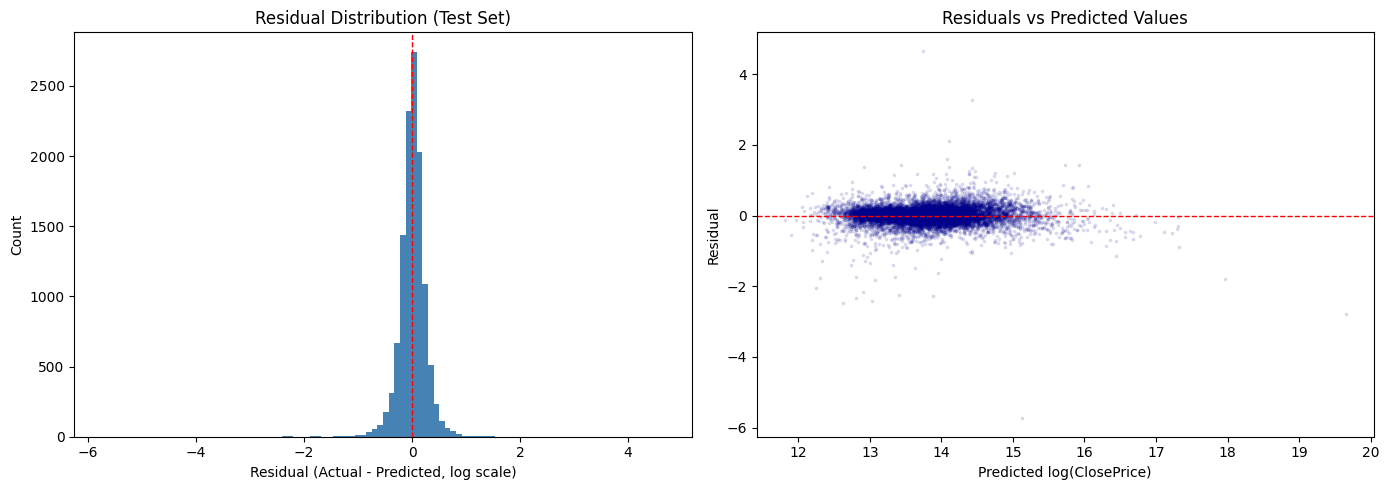

In [138]:
import matplotlib.pyplot as plt

residuals_test = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of residuals
axes[0].hist(residuals_test, bins=100, color="steelblue")
axes[0].set_title("Residual Distribution (Test Set)")
axes[0].set_xlabel("Residual (Actual - Predicted, log scale)")
axes[0].set_ylabel("Count")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)

# Residuals vs Predicted (check for patterns)
axes[1].scatter(y_pred_test, residuals_test, alpha=0.1, s=3, color="darkblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Residuals vs Predicted Values")
axes[1].set_xlabel("Predicted log(ClosePrice)")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


In [139]:
test_df_with_resid = test_df.copy()
test_df_with_resid["predicted_log_price"] = y_pred_test
test_df_with_resid["residual"] = residuals_test.values

print("Top 10 UNDER-predicted (actual price much higher than predicted):")
print(
    test_df_with_resid.nlargest(10, "residual")[
        [
            "ClosePrice",
            "predicted_log_price",
            "residual",
            "LivingArea",
        ]
    ]
)

print("\nTop 10 OVER-predicted (actual price much lower than predicted):")
print(
    test_df_with_resid.nsmallest(10, "residual")[
        [
            "ClosePrice",
            "predicted_log_price",
            "residual",
            "LivingArea",
        ]
    ]
)


Top 10 UNDER-predicted (actual price much higher than predicted):
         ClosePrice  predicted_log_price  residual  LivingArea
10189 97972500.0000              13.7360    4.6642   2254.0000
8124  48720000.0000              14.4255    3.2761   1800.0000
1329  11150000.0000              14.1067    2.1203   2028.0000
11816  6400000.0000              14.0827    1.5891      0.0000
1955   2900000.0000              13.4376    1.4427   2228.0000
46    35000000.0000              15.9301    1.4407   5154.0000
391   28000000.0000              15.7259    1.4218   6315.0000
180    5300000.0000              14.1063    1.3769   1189.0000
2884   1600000.0000              12.9203    1.3652   1526.0000
53     7095000.0000              14.4287    1.3462   4157.0000

Top 10 OVER-predicted (actual price much lower than predicted):
         ClosePrice  predicted_log_price  residual  LivingArea
5211     11900.0000              15.1206   -5.7363   4316.0000
12015 21500000.0000              19.6541   -2.7706

In [140]:
lower_cap = train_df["price_ratio"].quantile(0.005)
upper_cap = train_df["price_ratio"].quantile(0.9995)
print(f"Lower cap: {lower_cap:.4f}, Upper cap: {upper_cap:.4f}")

train_mask = (train_df["price_ratio"] >= lower_cap) & (
    train_df["price_ratio"] <= upper_cap
)
val_mask = (val_df["price_ratio"] >= lower_cap) & (val_df["price_ratio"] <= upper_cap)
test_mask = (test_df["price_ratio"] >= lower_cap) & (
    test_df["price_ratio"] <= upper_cap
)

print(
    f"Train: {train_mask.sum()} / {len(train_df)} kept ({(1 - train_mask.mean()) * 100:.4f}% removed)"
)
print(
    f"Val: {val_mask.sum()} / {len(val_df)} kept ({(1 - val_mask.mean()) * 100:.4f}% removed)"
)
print(
    f"Test: {test_mask.sum()} / {len(test_df)} kept ({(1 - test_mask.mean()) * 100:.4f}% removed)"
)


Lower cap: 0.7893, Upper cap: 1.9807
Train: 128764 / 129477 kept (0.5507% removed)
Val: 31553 / 31739 kept (0.5860% removed)
Test: 11955 / 12017 kept (0.5159% removed)


In [141]:
X_train_no_outliers = X_train_scaled[train_mask]
y_train_no_outliers = y_train[train_mask]

X_val_no_outliers = X_val_scaled[val_mask]
y_val_no_outliers = y_val[val_mask]

X_test_no_outliers = X_test_scaled[test_mask]
y_test_no_outliers = y_test[test_mask]


In [142]:
model_no_outliers = LinearRegression()
model_no_outliers.fit(X_train_no_outliers, y_train_no_outliers)

y_pred_train_no = model_no_outliers.predict(X_train_no_outliers)

r2_train_no = r2_score(y_train_no_outliers, y_pred_train_no)
rmse_train_no = np.sqrt(mean_squared_error(y_train_no_outliers, y_pred_train_no))
mae_train_no = mean_absolute_error(y_train_no_outliers, y_pred_train_no)

print(f"Train R² (no outliers):   {r2_train_no:.4f}")
print(f"Train RMSE (no outliers, log scale): {rmse_train_no:.4f}")
print(f"Train MAE  (no outliers, log scale): {mae_train_no:.4f}")


Train R² (no outliers):   0.8822
Train RMSE (no outliers, log scale): 0.2271
Train MAE  (no outliers, log scale): 0.1601


In [143]:
y_pred_val_no = model_no_outliers.predict(X_val_no_outliers)

r2_val_no = r2_score(y_val_no_outliers, y_pred_val_no)
rmse_val_no = np.sqrt(mean_squared_error(y_val_no_outliers, y_pred_val_no))
mae_val_no = mean_absolute_error(y_val_no_outliers, y_pred_val_no)

print(f"Val R² (no outliers):   {r2_val_no:.4f}")
print(f"Val RMSE (no outliers, log scale): {rmse_val_no:.4f}")
print(f"Val MAE  (no outliers, log scale): {mae_val_no:.4f}")


Val R² (no outliers):   0.8783
Val RMSE (no outliers, log scale): 0.2359
Val MAE  (no outliers, log scale): 0.1666


In [144]:
y_pred_test_no = model_no_outliers.predict(X_test_no_outliers)

r2_test_no = r2_score(y_test_no_outliers, y_pred_test_no)
rmse_test_no = np.sqrt(mean_squared_error(y_test_no_outliers, y_pred_test_no))
mae_test_no = mean_absolute_error(y_test_no_outliers, y_pred_test_no)

print(f"Test R² (no outliers):   {r2_test_no:.4f}")
print(f"Test RMSE (no outliers, log scale): {rmse_test_no:.4f}")
print(f"Test MAE  (no outliers, log scale): {mae_test_no:.4f}")


Test R² (no outliers):   0.8794
Test RMSE (no outliers, log scale): 0.2337
Test MAE  (no outliers, log scale): 0.1667


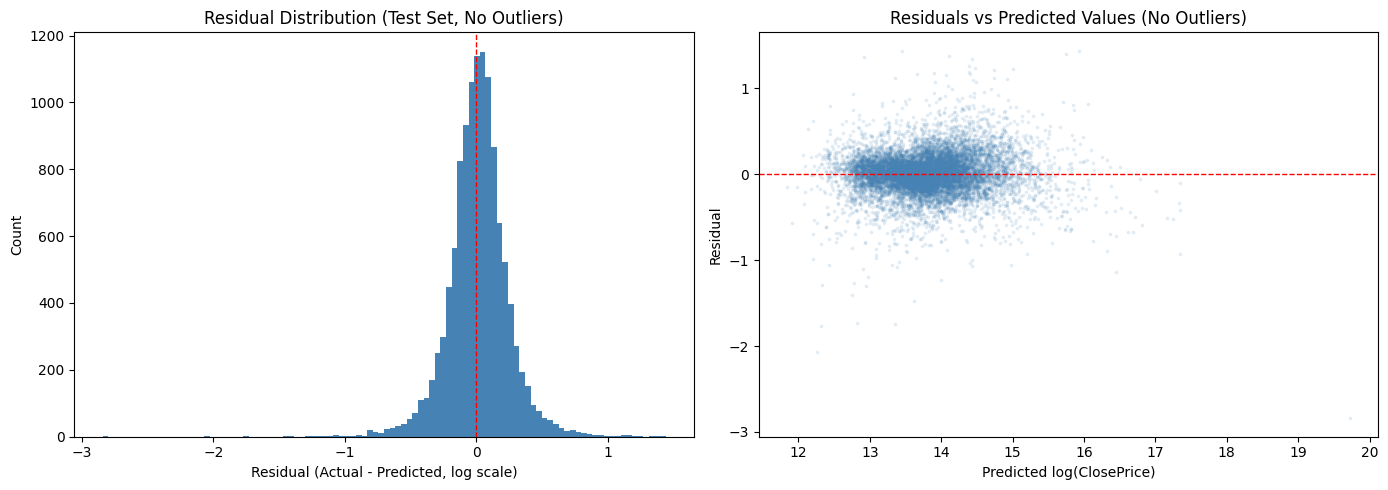

In [145]:
residuals_test_no = y_test_no_outliers - y_pred_test_no

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals_test_no, bins=100, color="steelblue")
axes[0].set_title("Residual Distribution (Test Set, No Outliers)")
axes[0].set_xlabel("Residual (Actual - Predicted, log scale)")
axes[0].set_ylabel("Count")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)

axes[1].scatter(y_pred_test_no, residuals_test_no, alpha=0.1, s=3, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Residuals vs Predicted Values (No Outliers)")
axes[1].set_xlabel("Predicted log(ClosePrice)")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


In [146]:
comparison = pd.DataFrame(
    [
        {
            "version": "With Outliers",
            "Train_R2": r2_train,
            "Val_R2": r2_val,
            "Test_R2": r2_test,
        },
        {
            "version": "No Outliers",
            "Train_R2": r2_train_no,
            "Val_R2": r2_val_no,
            "Test_R2": r2_test_no,
        },
    ]
)
print(comparison)


         version  Train_R2  Val_R2  Test_R2
0  With Outliers    0.8607  0.8528   0.8602
1    No Outliers    0.8822  0.8783   0.8794


In [147]:
train_no_outliers_export = X_train_no_outliers.copy()
train_no_outliers_export["log_price"] = y_train_no_outliers
train_no_outliers_export["ClosePrice"] = train_df.loc[
    X_train_no_outliers.index, "ClosePrice"
]
train_no_outliers_export["CloseDate"] = train_df.loc[
    X_train_no_outliers.index, "CloseDate"
]
train_no_outliers_export.to_csv("train_no_outliers.csv", index=False)

val_no_outliers_export = X_val_no_outliers.copy()
val_no_outliers_export["log_price"] = y_val_no_outliers
val_no_outliers_export["ClosePrice"] = val_df.loc[X_val_no_outliers.index, "ClosePrice"]
val_no_outliers_export["CloseDate"] = val_df.loc[X_val_no_outliers.index, "CloseDate"]
val_no_outliers_export.to_csv("validation_no_outliers.csv", index=False)

test_no_outliers_export = X_test_no_outliers.copy()
test_no_outliers_export["log_price"] = y_test_no_outliers
test_no_outliers_export["ClosePrice"] = test_df.loc[
    X_test_no_outliers.index, "ClosePrice"
]
test_no_outliers_export["CloseDate"] = test_df.loc[
    X_test_no_outliers.index, "CloseDate"
]
test_no_outliers_export.to_csv("test_no_outliers.csv", index=False)

print(f"train_no_outliers.csv: {train_no_outliers_export.shape}")


train_no_outliers.csv: (128764, 38)
